# 🛒 A Practical Showcase of Sequential Recommendations Using GRU4Rec on the OTTO Dataset

In this notebook, cutting-edge technologies are applied to real-world data to build a **personalized recommendation system** for users on an e-commerce platform.

**RecBole**, a powerful deep learning-based recommendation framework, is beign used to implement **GRU4Rec** a state-of-the-art **sequential collaborative filtering model**. This allows us to predict the next likely item a user will interact with based on their recent behavior.

The dataset powering this project is the **[OTTO Recommender Systems Dataset](https://github.com/otto-de/recsys-dataset)**, which is based on **real user interaction data** from the OTTO online retail platform. It contains millions of anonymized events such as clicks, cart additions, and purchases, and reflects realistic user behavior in an online store.

---

🔍 **Goals of this notebook:**
- Preprocess and filter OTTO dataset for sequential modeling
- Train a GRU4Rec model using RecBole and evaluate it by using ranking metrics like Recall@10 and MRR@10
- Generate top-N product recommendations for individual user sessions

## 🧠 Introduction to Recommendation Systems

A **recommendation system** is a machine learning model that suggests relevant content, products, or actions to users by learning from their **past behavior** and **real-time interactions**.

There are several types of recommendation systems, commonly including:
- **Collaborative filtering**: Learns from patterns of users and items (e.g. "users like you also liked...")
- **Content-based filtering**: Recommends items similar to those the user has interacted with (e.g. similar genre, brand, or features)
- **Hybrid models**: Combine collaborative and content-based methods to overcome limitations of each approach

Below is a simplified diagram illustrating how a user interacts with different types of content (like actors, songs, or movies), and how those actions feed into the recommendation system to generate personalized suggestions:

![](https://miro.medium.com/v2/resize:fit:1400/1*6gDIv9mWyc8vkdGerBKiXw.jpeg)

### Install RecBole for this notebook

In [1]:
!pip install recbole

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.1/57.1 MB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 82.8 MB/s eta 0:00:00
  Attempting uninstall: colorlog
    Found existing installation: colorlog 6.9.0
    Uninstalling colorlog-6.9.0:
      Successfully uninstalled colorlog-6.9.0
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.9.41
    Uninstalling

### 📂 Load and Explore the Data

For this notebook, we will be using the **smaller version** of the OTTO dataset in `.parquet` format, which is more memory-efficient and suitable for interactive analysis.

To efficiently load and work with the data, we use the **Polars** library instead of pandas. Polars offers significant performance benefits for large tabular datasets due to its Rust-based backend and support for multi-threaded operations.

Due to memory restriction on Kaggle, we will be loading the last week of training data and the testing set

In [2]:
import polars as pl

In [3]:
# RecBole expects an atomic file, which we create here
# more information: https://recbole.io/atomic_files.html

train = pl.read_parquet('/kaggle/input/otto-train-and-test-data-for-local-validation/test.parquet')
test = pl.read_parquet('/kaggle/input/otto-full-optimized-memory-footprint/test.parquet')

df = pl.concat([train, test])

df = df.sort(['session', 'aid', 'ts'])
df = df.with_columns((pl.col('ts') * 1e9).alias('ts')) # unix nanoseconds are expected by RecBole
df = df.rename({'session': 'session:token', 'aid': 'aid:token', 'ts': 'ts:float'}) # the columnname including :[type] is expected by RecBole

!mkdir /kaggle/working/recbox_data
df['session:token', 'aid:token', 'ts:float'].write_csv('/kaggle/working/recbox_data/recbox_data.inter', separator='\t')

In [4]:
df

session:token,aid:token,ts:float,type
i32,i32,f64,u8
11098528,11830,1.6611e18,0
11098529,1105029,1.6611e18,0
11098530,264500,1.6611e18,0
11098530,264500,1.6611e18,0
11098530,409236,1.6611e18,0
…,…,…,…
14571577,1141710,1.6623e18,0
14571578,519105,1.6623e18,0
14571579,739876,1.6623e18,0


For our dataset there are 3 types "clicked" - 0, "cart" - 1 and "order" - 2 these strings are being transformed into ints here to safe diskspace.

In [5]:
df.filter(pl.col("session:token") == 11098530), df.filter(pl.col("session:token") == 11098556), df.filter(pl.col("session:token") == 12899775)

(shape: (6, 4)
 ┌───────────────┬───────────┬───────────┬──────┐
 │ session:token ┆ aid:token ┆ ts:float  ┆ type │
 │ ---           ┆ ---       ┆ ---       ┆ ---  │
 │ i32           ┆ i32       ┆ f64       ┆ u8   │
 ╞═══════════════╪═══════════╪═══════════╪══════╡
 │ 11098530      ┆ 264500    ┆ 1.6611e18 ┆ 0    │
 │ 11098530      ┆ 264500    ┆ 1.6611e18 ┆ 0    │
 │ 11098530      ┆ 409236    ┆ 1.6611e18 ┆ 0    │
 │ 11098530      ┆ 409236    ┆ 1.6611e18 ┆ 0    │
 │ 11098530      ┆ 409236    ┆ 1.6611e18 ┆ 0    │
 │ 11098530      ┆ 409236    ┆ 1.6611e18 ┆ 1    │
 └───────────────┴───────────┴───────────┴──────┘,
 shape: (15, 4)
 ┌───────────────┬───────────┬───────────┬──────┐
 │ session:token ┆ aid:token ┆ ts:float  ┆ type │
 │ ---           ┆ ---       ┆ ---       ┆ ---  │
 │ i32           ┆ i32       ┆ f64       ┆ u8   │
 ╞═══════════════╪═══════════╪═══════════╪══════╡
 │ 11098556      ┆ 121148    ┆ 1.6611e18 ┆ 0    │
 │ 11098556      ┆ 153333    ┆ 1.6611e18 ┆ 0    │
 │ 11098556      ┆

In these example sessions 11098530, 11098556 and 12899775: users looked at different items and acted differently. The session 11098530 resulted in a couple of item clicks but there was no order, one item has been added to the cart at the end of the session. While session 11098556 added an item to the cart the session continued by looking at different items. In contrast to the other two sessions, session 12899775 is an one click event, clicking at one item (viewing it) and ending the session afterwards.

Session-based recommenders ensure that even when cookies are being declined, users can still receive relevant recommendations. These models rely solely on real-time activity within the current session such as clicks or views without requiring any long-term user history or identification. In use cases like ours, where each visit is treated as a new anonymous session, the recommender adapts instantly to session behavior, making it privacy friendly and effective for first-time or unlogged users.

In [6]:
import logging
from logging import getLogger
from recbole.config import Config
from recbole.data import create_dataset, data_preparation
from recbole.model.sequential_recommender import GRU4Rec
from recbole.trainer import Trainer
from recbole.utils import init_seed, init_logger

from recbole.utils.case_study import full_sort_topk

2025-07-30 08:34:31.985577: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753864472.204653      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753864472.267949      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## 🔁 GRU4Rec – Sequential Recommender with GRUs

The model we are using is **GRU4Rec**, a powerful sequential recommendation model based on **Recurrent Neural Networks (RNNs)**, specifically using **Gated Recurrent Units (GRUs)**.

The architecture begins with an **embedding layer**, which transforms each item into a dense vector representation. These embeddings are passed through **multiple GRU layers**, which capture the **sequential patterns** in a user's interactions. The model then outputs a **score for each possible item**, representing how likely it is to be the next item the user interacts with.

GRU4Rec is a **collaborative filtering model**, as it learns purely from **user-item interaction sequences**. It does not use any side information (e.g. item metadata, user profiles).  
In real-world applications, it's often beneficial to use **hybrid models**, which combine interaction data with **content features** for improved personalization and cold-start performance.

![](https://www.researchgate.net/publication/324055051/figure/fig3/AS:962202051821599@1606418254544/Architecture-of-the-gru4rec-neural-network-Adapted-from-Hidasi-etal-2016a.png)
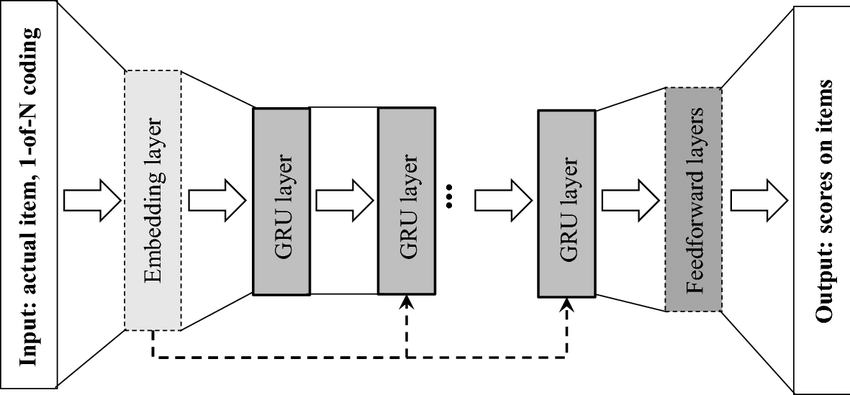
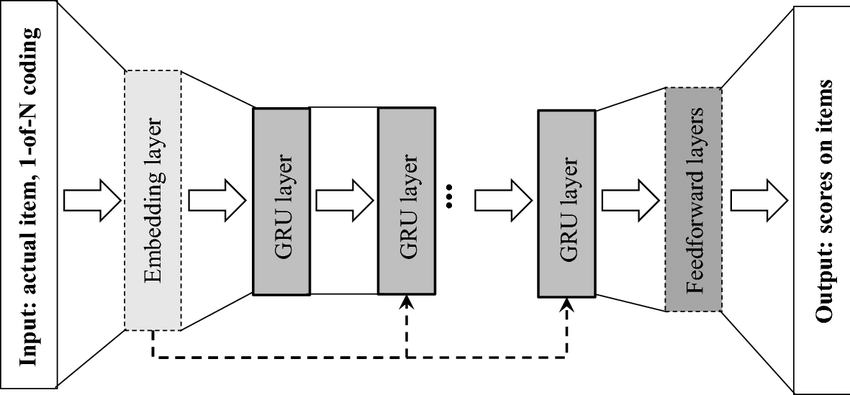
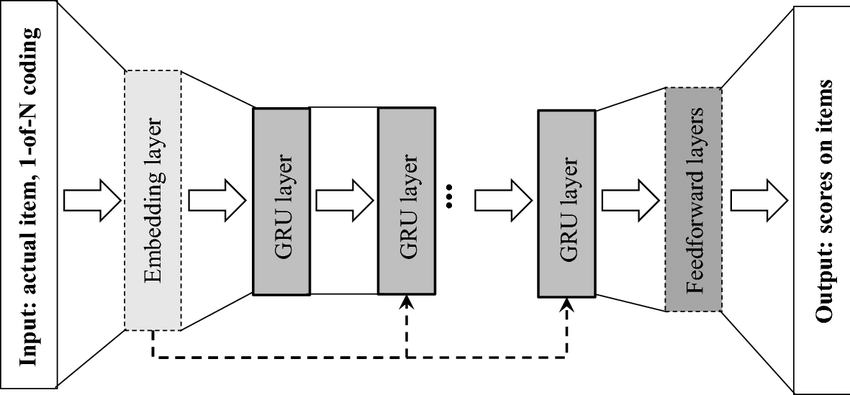

In [7]:
MAX_ITEM = 20  # limit the input sequence to the last 20 items a user interacted with

parameter_dict = {
    'data_path': '/kaggle/working/',              # path where the data (e.g. inter.csv) is stored
    'USER_ID_FIELD': 'session',                   # field used to identify users (sessions in this case)
    'ITEM_ID_FIELD': 'aid',                       # field used to identify items
    'TIME_FIELD': 'ts',                           # timestamp field for ordering interactions
    'user_inter_num_interval': "[5,Inf)",         # keep users with at least 5 interactions
    'item_inter_num_interval': "[5,Inf)",         # keep items with at least 5 interactions
    'load_col': {'inter': ['session', 'aid', 'ts']},  # load only these columns from the interaction file
    'train_neg_sample_args': None,                # no negative sampling (use full item ranking)
    'epochs': 10,                                 # number of training epochs
    'stopping_step': 3,                           # stop early if no improvement after 3 valid steps

    'eval_batch_size': 1024,                      # batch size during evaluation
    # 'train_batch_size': 1024,                   # (optional) batch size for training
    # 'enable_amp': True,                         # (optional) enable mixed-precision training
    'MAX_ITEM_LIST_LENGTH': MAX_ITEM,             # max number of past items used in sequence
    'eval_args': {
        'split': {'RS': [9, 1, 0]},               # random split: 90% train, 10% valid, 0% test
        'group_by': 'user',                       # group data per user/session
        'order': 'TO',                            # respect temporal order
        'mode': 'full'                            # use full item list for evaluation
    }
}

# initialize RecBole with the GRU4Rec model, dataset name, and custom parameters 
config = Config(model='GRU4Rec', dataset='recbox_data', config_dict=parameter_dict)

# init random seed
init_seed(config['seed'], config['reproducibility'])

# logger initialization
init_logger(config)
logger = getLogger()

# create handlers
c_handler = logging.StreamHandler()
c_handler.setLevel(logging.INFO)
logger.addHandler(c_handler)

# write config info into log
logger.info(config)


General Hyper Parameters:
gpu_id = 0
use_gpu = True
seed = 2020
state = INFO
reproducibility = True
data_path = /kaggle/working/recbox_data
checkpoint_dir = saved
show_progress = True
save_dataset = False
dataset_save_path = None
save_dataloaders = False
dataloaders_save_path = None
log_wandb = False

Training Hyper Parameters:
epochs = 10
train_batch_size = 2048
learner = adam
learning_rate = 0.001
train_neg_sample_args = {'distribution': 'none', 'sample_num': 'none', 'alpha': 'none', 'dynamic': False, 'candidate_num': 0}
eval_step = 1
stopping_step = 3
clip_grad_norm = None
weight_decay = 0.0
loss_decimal_place = 4

Evaluation Hyper Parameters:
eval_args = {'split': {'RS': [9, 1, 0]}, 'order': 'TO', 'group_by': 'user', 'mode': {'valid': 'full', 'test': 'full'}}
repeatable = True
metrics = ['Recall', 'MRR', 'NDCG', 'Hit', 'Precision']
topk = [10]
valid_metric = MRR@10
valid_metric_bigger = True
eval_batch_size = 1024
metric_decimal_place = 4

Dataset Hyper Parameters:
field_separator

In [8]:
# create the dataset based on our configurations
dataset = create_dataset(config)
logger.info(dataset)

/usr/local/lib/python3.11/dist-packages/recbole/data/dataset/dataset.py:648: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  feat[field].fillna(value=0, inplace=True)
/usr/local/lib/python3.11/dist-packages/recbole/data/dataset/dataset.py:650: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a c

## Training

With our data prepared and processed into sequential format, we now train the **GRU4Rec** model using the RecBole framework.

GRU4Rec will learn to predict the next likely item a user will interact with, based solely on the sequence of actions within each session. This allows the model to generate personalized, session-aware recommendations without requiring long-term user tracking.

In [9]:
# prepare the dataset by splitting it into train, valid and test chunks
train_data, valid_data, test_data = data_preparation(config, dataset)

[Training]: train_batch_size = [2048] train_neg_sample_args: [{'distribution': 'none', 'sample_num': 'none', 'alpha': 'none', 'dynamic': False, 'candidate_num': 0}]
[Evaluation]: eval_batch_size = [1024] eval_args: [{'split': {'RS': [9, 1, 0]}, 'order': 'TO', 'group_by': 'user', 'mode': {'valid': 'full', 'test': 'full'}}]


In [10]:
# model loading and initialization
model = GRU4Rec(config, train_data.dataset).to(config['device'])
logger.info(model)

# trainer loading and initialization
trainer = Trainer(config, model)

# model training
best_valid_score, best_valid_result = trainer.fit(train_data, valid_data)

GRU4Rec(
  (item_embedding): Embedding(315004, 64, padding_idx=0)
  (emb_dropout): Dropout(p=0.3, inplace=False)
  (gru_layers): GRU(64, 128, bias=False, batch_first=True)
  (dense): Linear(in_features=128, out_features=64, bias=True)
  (loss_fct): CrossEntropyLoss()
)
Trainable parameters: 20242240
/usr/local/lib/python3.11/dist-packages/recbole/trainer/trainer.py:235: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = amp.GradScaler(enabled=self.enable_scaler)
epoch 0 training [time: 932.55s, train loss: 32493.9025]
epoch 0 evaluating [time: 85.49s, valid_score: 0.128500]
valid result: 
recall@10 : 0.2401    mrr@10 : 0.1285    ndcg@10 : 0.1548    hit@10 : 0.2401    precision@10 : 0.024
Saving current: saved/GRU4Rec-Jul-30-2025_08-39-56.pth
epoch 1 training [time: 946.39s, train loss: 23487.8303]
epoch 1 evaluating [time: 85.29s, valid_score: 0.223400]
valid result: 
recall@10 : 0.3763    mrr@10 : 0

### Evaluation Metrics Explained

- **Recall@10**: Measures the proportion of relevant items successfully retrieved in the top 10 recommendations.

- **MRR@10 (Mean Reciprocal Rank)**: Evaluates how highly the first relevant item is ranked in the top 10 list. A higher score indicates the relevant item appears earlier.

- **NDCG@10 (Normalized Discounted Cumulative Gain)**: Considers both the relevance and the rank position of items, giving more credit when relevant items are ranked higher.

- **Hit@10**: Indicates whether at least one relevant item appears in the top 10. A simple check for presence, regardless of position.

- **Precision@10**: Calculates the proportion of the top 10 recommended items that are actually relevant.


In this case, our model continues to improve steadily during training, whereas models often begin to lose momentum or overfit in later stages.
In a real-world scenario, it is recommended to increase the number of training epochs and rely on early stopping based on validation performance. This ensures that the best-performing model is selected automatically, without the need to guess the optimal stopping point manually. We could further improve the model's performance using techniques like a learning rate scheduler or tuning the model’s dimensionality. However, for showcase purposes, this setup is sufficient and provides a solid baseline.

## Inference

Now that the model is trained, we will define a function that recommends the top 10 items for a given user session.
Using a session_id, the function will analyze the user's interaction history within that session and predict which items are most relevant to recommend next.

In [11]:
import torch
from recbole.data.interaction import Interaction
from recbole.utils.case_study import full_sort_scores

def recommend_for_sessions(external_session_id, model, dataset, top_k=10):
     # Convert external session ID to internal
    internal_session_id = dataset.token2id('session', external_session_id)

    # load interaction data
    inter_feat = dataset.inter_feat
    inter_df = pl.DataFrame({
        'session': inter_feat['session'].tolist(),
        'aid': inter_feat['aid'].tolist(),
        'ts': inter_feat['ts'].tolist(),
    })

    # filter and sort session history
    session_history = (
        inter_df
        .filter(pl.col('session') == internal_session_id)
        .sort('ts')
    )
    internal_item_ids = session_history['aid'].to_list()

    # prepare interaction
    item_list_field = dataset.iid_field + '_list'
    user_field = dataset.uid_field

    interaction = Interaction({
        user_field: torch.tensor([internal_session_id]),
        item_list_field: torch.tensor([internal_item_ids]),
        'item_length': torch.tensor([len(internal_item_ids)]),
    })

    # predict scores
    model.eval()
    scores = model.full_sort_predict(interaction.to(model.device))
    top_k_indices = torch.topk(scores[0], k=top_k).indices.tolist()
    external_item_ids = dataset.id2token(dataset.iid_field, top_k_indices)

    # print result
    print(f"Top {top_k} recommended items for session {external_session_id}:")
    for internal_id, external_id in zip(top_k_indices, external_item_ids):
        print(f"  Internal ID: {internal_id}  →  External ID: {external_id}")

Please note, that RecBole maps our external article/session ids e.g. [1855508, 535924, 214372, ...] to internal ids e.g. [0, 1, 2, ...]

To make that clear, I'm printing both ids, which still represents the same article

In [12]:
recommend_for_sessions('11098556', model, dataset, top_k=10)

Top 10 recommended items for session 11098556:
  Internal ID: 148  →  External ID: 535924
  Internal ID: 146  →  External ID: 214372
  Internal ID: 152  →  External ID: 1855508
  Internal ID: 147  →  External ID: 527209
  Internal ID: 219294  →  External ID: 953725
  Internal ID: 144  →  External ID: 121148
  Internal ID: 3448  →  External ID: 1828260
  Internal ID: 148681  →  External ID: 993914
  Internal ID: 151  →  External ID: 1724341
  Internal ID: 123147  →  External ID: 1069345


In [13]:
recommend_for_sessions('11098530', model, dataset, top_k=10)

Top 10 recommended items for session 11098530:
  Internal ID: 2  →  External ID: 409236
  Internal ID: 11100  →  External ID: 210880
  Internal ID: 1  →  External ID: 264500
  Internal ID: 23347  →  External ID: 583026
  Internal ID: 21156  →  External ID: 963957
  Internal ID: 15058  →  External ID: 1282899
  Internal ID: 23348  →  External ID: 752334
  Internal ID: 199551  →  External ID: 1677181
  Internal ID: 470  →  External ID: 1603001
  Internal ID: 173347  →  External ID: 235691


In [14]:
recommend_for_sessions('11098533', model, dataset, top_k=10)

Top 10 recommended items for session 11098533:
  Internal ID: 79285  →  External ID: 1591125
  Internal ID: 18  →  External ID: 1074173
  Internal ID: 180306  →  External ID: 1590427
  Internal ID: 17829  →  External ID: 1371098
  Internal ID: 21  →  External ID: 1622419
  Internal ID: 16  →  External ID: 978918
  Internal ID: 49685  →  External ID: 340001
  Internal ID: 85112  →  External ID: 672735
  Internal ID: 163180  →  External ID: 1146523
  Internal ID: 6376  →  External ID: 1188296


Based on the session history of session 11098533, the model predicts that the most relevant next items to recommend are (in order of highest to lowest predicted score):
1074173, 978918, 1622419, ...

These are the external item IDs, representing the top-ranked items according to the model’s confidence.